***1- Imports & Data loading***

In [ ]:
import os                                                                                              
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'                                                          
os.environ['OMP_NUM_THREADS'] = '1'
                                                                                            
import pandas as pd
import numpy as np                                                                                     
from pathlib import Path                                                                             
                                                                                                    
# IMPORTANT: import torch BEFORE sklearn to avoid libomp segfault on macOS                             
# both libraries ship their own copy of libomp — torch's must load first
import torch                                                                                           
import torch.nn as nn                                                                                
                                                                                                  
from sklearn.linear_model import LogisticRegression, LinearRegression                                  
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor                                   
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor                                 
from sklearn.metrics import (accuracy_score, precision_score, recall_score,                          
                            f1_score, roc_auc_score, mean_absolute_error,                              
                            mean_squared_error, r2_score)
import xgboost as xgb                                                                                  
import warnings                                                                                        
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent

# ---- Load UNSCALED data (for sklearn + XGBoost) ----
train_df = pd.read_parquet(ROOT / 'data' / 'train.parquet')
val_df   = pd.read_parquet(ROOT / 'data' / 'val.parquet')
test_df  = pd.read_parquet(ROOT / 'data' / 'test.parquet')

# ---- Load SCALED data (for PyTorch) ----
train_scaled = pd.read_parquet(ROOT / 'data' / 'train_scaled.parquet')
val_scaled   = pd.read_parquet(ROOT / 'data' / 'val_scaled.parquet')
test_scaled  = pd.read_parquet(ROOT / 'data' / 'test_scaled.parquet')

target_cols = ['dim_flag', 'log_net_charge', 'Net Charge Billed Currency']
feature_cols = [c for c in train_df.columns if c not in target_cols]

# sklearn/XGBoost features and targets
X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]

y_train_cls = train_df['dim_flag']
y_test_cls  = test_df['dim_flag']

y_train_reg = train_df['log_net_charge']
y_test_reg  = test_df['log_net_charge']

y_test_actual_dollars = test_df['Net Charge Billed Currency'].values

# PyTorch tensors (scaled features)
feature_cols_scaled = [c for c in train_scaled.columns if c not in target_cols]
X_test_tensor = torch.tensor(test_scaled[feature_cols_scaled].values, dtype=torch.float32)

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Features: 34
Train: 41,820 | Test: 5,228


***2- Retrain ALL sklearn/XGboost Models***

In [2]:
# ---- Logistic Regression (classification) ----
lr_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_clf.fit(X_train, y_train_cls)

# ---- Linear Regression (regression) ----
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train_reg)

# ---- AdaBoost Classification ----
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_clf.fit(X_train, y_train_cls)

# ---- AdaBoost Regression ----
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_reg.fit(X_train, y_train_reg)

# ---- XGBoost Classification ----
# need val set for early stopping only
X_val = val_df[feature_cols]
y_val_cls = val_df['dim_flag']
y_val_reg = val_df['log_net_charge']

neg_count = (y_train_cls == 0).sum()
pos_count = (y_train_cls == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=neg_count / pos_count,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0,
    nthread=1
)
xgb_clf.fit(X_train, y_train_cls, eval_set=[(X_val, y_val_cls)], verbose=False)

# ---- XGBoost Regression ----
xgb_reg = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0,
    nthread=1
)
xgb_reg.fit(X_train, y_train_reg, eval_set=[(X_val, y_val_reg)], verbose=False)

print("All sklearn/XGBoost models retrained.")
print(f"XGBoost Classifier stopped at {xgb_clf.best_iteration} trees")
print(f"XGBoost Regressor stopped at {xgb_reg.best_iteration} trees")

All sklearn/XGBoost models retrained.
XGBoost Classifier stopped at 63 trees
XGBoost Regressor stopped at 593 trees


***3- Load Pytorch Checkpoints***

In [5]:
# same 128→64→32→1 architecture as src/05 and src/06
# defined as plain nn.Module — Lightning is only needed for training, not inference

class DIMClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

class ShippingRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# Lightning checkpoints store weights under 'state_dict' key
# keys are already prefixed with 'net.' which matches our nn.Module attribute name
input_dim = len(feature_cols_scaled)

pt_clf = DIMClassifier(input_dim)
ckpt_clf = torch.load(ROOT / 'models' / 'pytorch_classifier_best.ckpt', map_location='cpu',
weights_only=False)
pt_clf.load_state_dict(ckpt_clf['state_dict'], strict=False)
pt_clf.eval()

pt_reg = ShippingRegressor(input_dim)
ckpt_reg = torch.load(ROOT / 'models' / 'pytorch_regressor_best.ckpt', map_location='cpu',
weights_only=False)
pt_reg.load_state_dict(ckpt_reg['state_dict'], strict=False)
pt_reg.eval()

print(f"Loaded PyTorch classifier and regressor (input_dim={input_dim})")

Loaded PyTorch classifier and regressor (input_dim=34)


***4- Evaluate All Models on Test Set (Classification)***

In [6]:
# ---- sklearn / XGBoost predictions ----
pred_lr   = lr_clf.predict(X_test)
prob_lr   = lr_clf.predict_proba(X_test)[:, 1]

pred_ada  = ada_clf.predict(X_test)
prob_ada  = ada_clf.predict_proba(X_test)[:, 1]

pred_xgb  = xgb_clf.predict(X_test)
prob_xgb  = xgb_clf.predict_proba(X_test)[:, 1]

# ---- PyTorch predictions ----
with torch.no_grad():
    pt_logits = pt_clf(X_test_tensor).squeeze()
    pt_probs  = torch.sigmoid(pt_logits).numpy()
pred_pt = (pt_probs >= 0.5).astype(int)

# ---- Compute metrics for each model ----
cls_models = {
    'Logistic Reg':  (pred_lr,  prob_lr),
    'AdaBoost':      (pred_ada, prob_ada),
    'XGBoost':       (pred_xgb, prob_xgb),
    'PyTorch FFNN':  (pred_pt,  pt_probs),
}

cls_results = []
for name, (preds, probs) in cls_models.items():
    cls_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test_cls, preds),
        'Precision': precision_score(y_test_cls, preds),
        'Recall':    recall_score(y_test_cls, preds),
        'F1':        f1_score(y_test_cls, preds),
        'ROC AUC':   roc_auc_score(y_test_cls, probs),
    })

cls_table = pd.DataFrame(cls_results).set_index('Model')

print("=" * 65)
print("CLASSIFICATION — TEST SET RESULTS")
print("=" * 65)
print(cls_table.to_string(float_format='{:.4f}'.format))

CLASSIFICATION — TEST SET RESULTS
              Accuracy  Precision  Recall     F1  ROC AUC
Model                                                    
Logistic Reg    0.9914     0.9815  0.9977 0.9895   0.9964
AdaBoost        0.9946     0.9907  0.9962 0.9935   0.9980
XGBoost         0.9979     0.9953  0.9995 0.9974   0.9990
PyTorch FFNN    0.9918     0.9811  0.9991 0.9900   0.9988


***9- Evaluate ALL Models on Test Set (Regression)***

In [7]:
# ---- sklearn / XGBoost predictions (log-space → dollars) ----
pred_lr_dollars  = np.expm1(lr_reg.predict(X_test))
pred_ada_dollars = np.expm1(ada_reg.predict(X_test))
pred_xgb_dollars = np.expm1(xgb_reg.predict(X_test))

# ---- PyTorch predictions (log-space → dollars) ----
with torch.no_grad():
    pt_pred_log = pt_reg(X_test_tensor).squeeze().numpy()
pred_pt_dollars = np.expm1(pt_pred_log)

# ---- Compute metrics for each model ----
reg_models = {
    'Linear Reg':   pred_lr_dollars,
    'AdaBoost':     pred_ada_dollars,
    'XGBoost':      pred_xgb_dollars,
    'PyTorch FFNN': pred_pt_dollars,
}

reg_results = []
for name, preds in reg_models.items():
    mae  = mean_absolute_error(y_test_actual_dollars, preds)
    rmse = np.sqrt(mean_squared_error(y_test_actual_dollars, preds))
    r2   = r2_score(y_test_actual_dollars, preds)
    reg_results.append({
        'Model': name,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'R²': r2,
    })

reg_table = pd.DataFrame(reg_results).set_index('Model')

print("=" * 55)
print("REGRESSION — TEST SET RESULTS")
print("=" * 55)
print(reg_table.to_string(float_format='{:.4f}'.format))

REGRESSION — TEST SET RESULTS
              MAE ($)  RMSE ($)     R²
Model                                 
Linear Reg     7.3058   12.6553 0.6954
AdaBoost      10.4450   15.7261 0.5297
XGBoost        4.2613    6.3708 0.9228
PyTorch FFNN   5.8742   10.1991 0.8022


***Side by side Comparison (Bar Charts)***

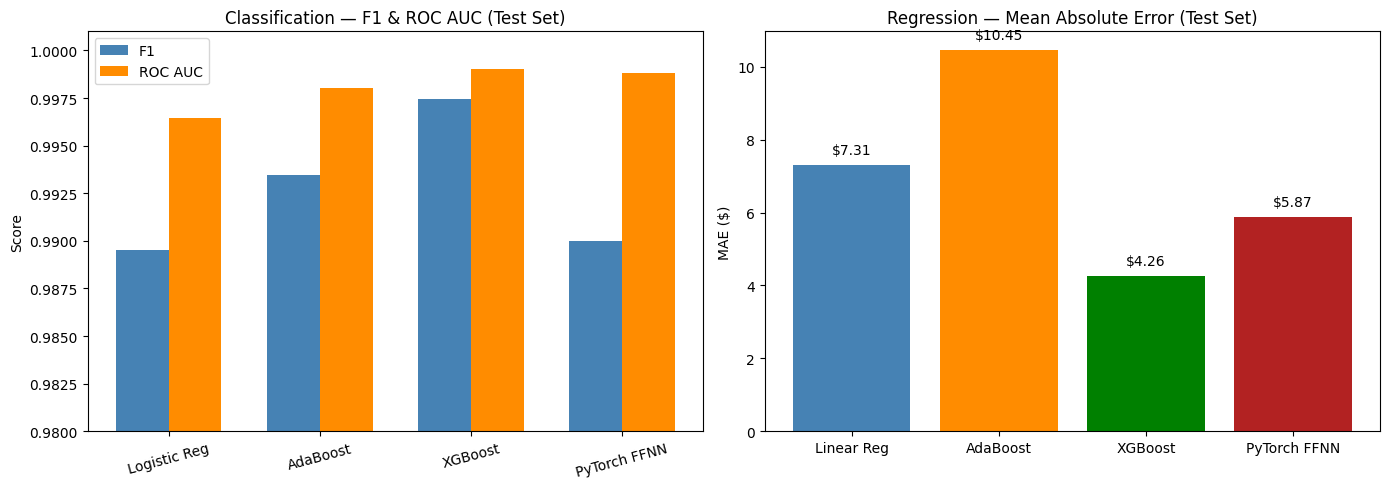

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Classification: F1 and ROC AUC ----
x = np.arange(len(cls_table))
width = 0.35

axes[0].bar(x - width/2, cls_table['F1'],      width, label='F1',      color='steelblue')
axes[0].bar(x + width/2, cls_table['ROC AUC'],  width, label='ROC AUC', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cls_table.index, rotation=15)
axes[0].set_ylim(0.98, 1.001)  # zoom in — all models are >0.98
axes[0].set_ylabel('Score')
axes[0].set_title('Classification — F1 & ROC AUC (Test Set)')
axes[0].legend()

# ---- Regression: MAE ----
colors = ['steelblue', 'darkorange', 'green', 'firebrick']
axes[1].bar(reg_table.index, reg_table['MAE ($)'], color=colors)
axes[1].set_ylabel('MAE ($)')
axes[1].set_title('Regression — Mean Absolute Error (Test Set)')
for i, v in enumerate(reg_table['MAE ($)']):
    axes[1].text(i, v + 0.3, f'${v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'final_comparison_bars.png', dpi=150)
plt.show()

***FInal Summary***

In [9]:
print("=" * 65)                                                                                        
print("FINAL MODEL COMPARISON — TEST SET")                                                             
print("=" * 65)                                                                                        
                                                                                                        
print("\n--- Task 1: Classification (DIM Flag) ---")                                                   
print(cls_table.to_string(float_format='{:.4f}'.format))                                               
                                                                                                        
print("\n--- Task 2: Regression (Net Charge $) ---")                                                   
print(reg_table.to_string(float_format='{:.4f}'.format))                                               
                                                                                                        
print("\n--- Best Models ---")                                                                         
best_cls = cls_table['F1'].idxmax()                                                                    
best_reg = reg_table['MAE ($)'].idxmin()                                                               
print(f"Classification: {best_cls} (F1 = {cls_table.loc[best_cls, 'F1']:.4f})")                        
print(f"Regression:     {best_reg} (MAE = ${reg_table.loc[best_reg, 'MAE ($)']:.2f})") 

FINAL MODEL COMPARISON — TEST SET

--- Task 1: Classification (DIM Flag) ---
              Accuracy  Precision  Recall     F1  ROC AUC
Model                                                    
Logistic Reg    0.9914     0.9815  0.9977 0.9895   0.9964
AdaBoost        0.9946     0.9907  0.9962 0.9935   0.9980
XGBoost         0.9979     0.9953  0.9995 0.9974   0.9990
PyTorch FFNN    0.9918     0.9811  0.9991 0.9900   0.9988

--- Task 2: Regression (Net Charge $) ---
              MAE ($)  RMSE ($)     R²
Model                                 
Linear Reg     7.3058   12.6553 0.6954
AdaBoost      10.4450   15.7261 0.5297
XGBoost        4.2613    6.3708 0.9228
PyTorch FFNN   5.8742   10.1991 0.8022

--- Best Models ---
Classification: XGBoost (F1 = 0.9974)
Regression:     XGBoost (MAE = $4.26)
